<a href="https://colab.research.google.com/github/marghistani22/Supervised-Machine-Learning/blob/main/notebooks_ma2273_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

home work 2
muska Arghistani


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv("DataProblem.csv")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (10000, 8)
Columns: ['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6']


,Unnamed: 0,0,1,2,3,4,5,6
0,0,0.492552,721.082614,5.042228,5.734170,2.112189,1.0,8.839982
1,1,4.390627,152.174641,6.075001,-78.633467,1.761183,3.0,-43.317974
2,2,-4.704564,655.334927,-0.742042,105.609595,1.543370,1.0,59.738018
3,3,-3.068747,789.916294,2.354023,20.049982,4.242583,4.0,8.852986
4,4,1.553264,346.778534,4.814482,3.598750,-0.491743,2.0,10.701917


# ## Data preparation
- Convert values to numeric if needed
- Drop missing values (safe step)
- Split into X (first 6 columns) and y (final column)

In [ ]:
# Remove index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convert to numeric and handle missing values
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna().reset_index(drop=True)

# Define features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (10000, 6) y shape: (10000,)


## Train/test split (required)
Use first 8000 rows for training and last 2000 for testing (preserve order).

In [ ]:
X_train, X_test = X.iloc[:8000], X.iloc[8000:]
y_train, y_test = y.iloc[:8000], y.iloc[8000:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8000, 6) (2000, 6) (8000,) (2000,)


## Scatterplots (predictors vs target)
We visualize relationships between each predictor and the target to see whether trends look linear,
non-linear, or weak.

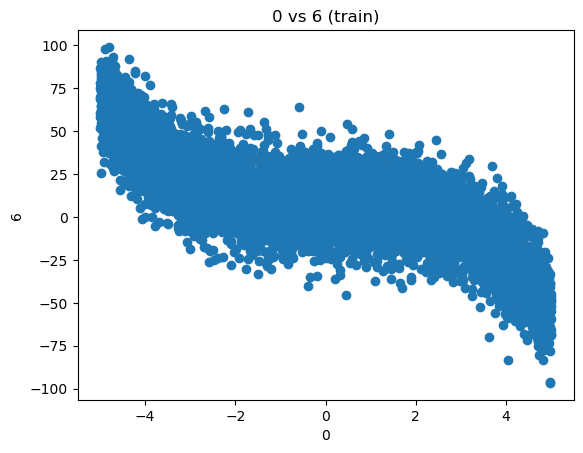

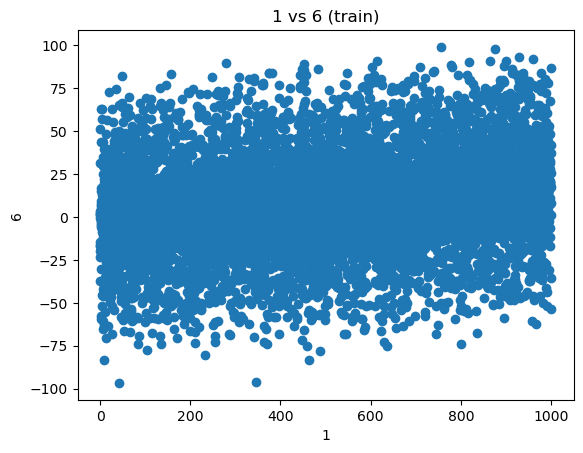

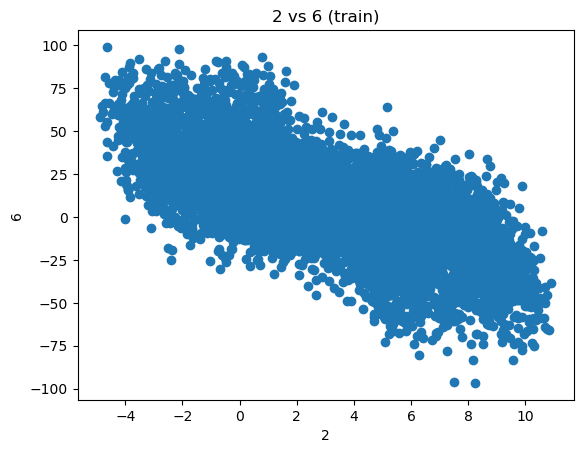

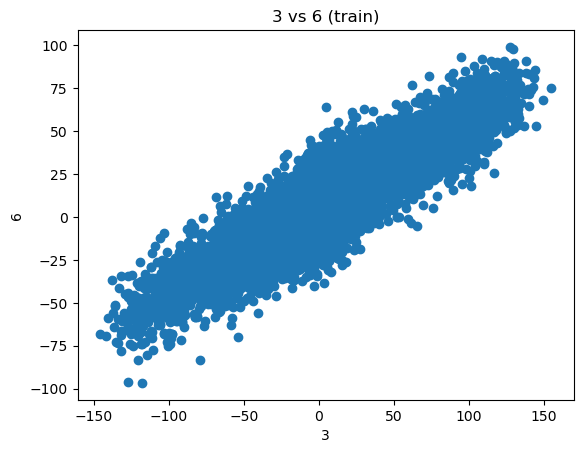

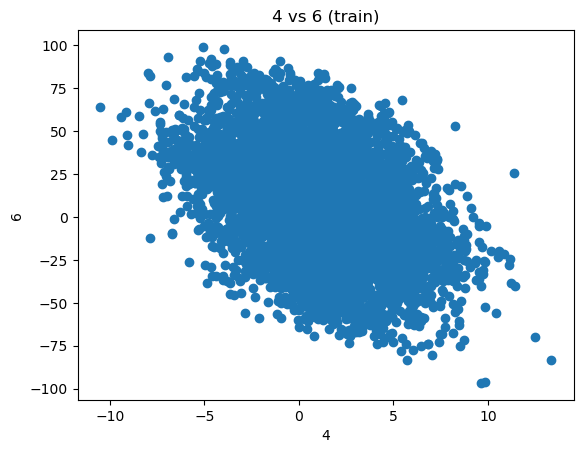

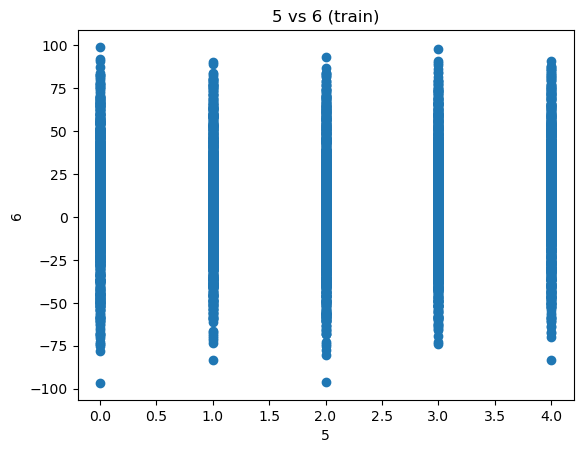

In [ ]:
target_name = df.columns[-1]

for col in X.columns:
    plt.figure()
    plt.scatter(X_train[col], y_train)
    plt.xlabel(col)
    plt.ylabel(target_name)
    plt.title(f"{col} vs {target_name} (train)")
    plt.show()

## Baseline model: Linear Regression + R²
R² measures how much variance in the target is explained by the model on unseen test data.

Interpretation:
- R² = 1.0: perfect predictions
- R² = 0.0: same as predicting the mean of y
- R² < 0.0: worse than predicting the mean (poor fit)
Higher is better.

In [ ]:
lin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

lin_model.fit(X_train, y_train)
y_pred_lr = lin_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
print("Test R² (Linear Regression):", r2_lr)

Test R² (Linear Regression): 1.0


In [ ]:
## Predicted vs Actual (test set)
If predictions are good, points should lie close to the diagonal line y = x.

<class 'SyntaxError'>: invalid syntax (<ipython-input-58-be82f8b4b4da>, line 2)

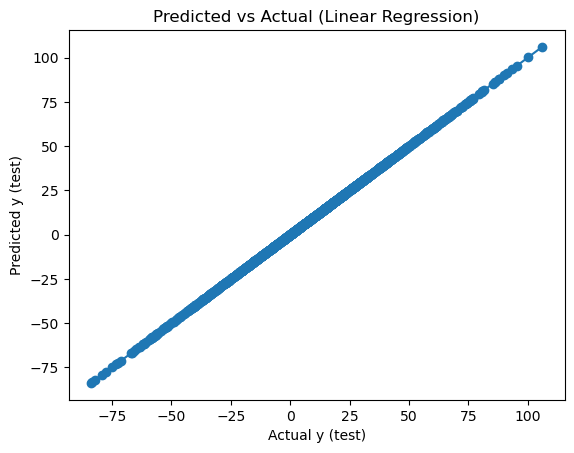

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual y (test)")
plt.ylabel("Predicted y (test)")
plt.title("Predicted vs Actual (Linear Regression)")

minv = min(y_test.min(), y_pred_lr.min())
maxv = max(y_test.max(), y_pred_lr.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()

In [ ]:
## Regularization: Ridge and Lasso
We use regularization to see if we can keep good performance while reducing/identifying less useful variables.

- Ridge (L2): shrinks coefficients, usually keeps all features.
- Lasso (L1): can set some coefficients to exactly 0 (feature elimination).
We tune alpha using cross-validation.

In [ ]:
alphas = np.logspace(-4, 4, 200)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Test R² (Ridge):", r2_ridge)
print("Best alpha (Ridge):", ridge_model.named_steps["ridge"].alpha_)

In [ ]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=5, max_iter=200000, random_state=0))
])
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Test R² (Lasso):", r2_lasso)
print("Best alpha (Lasso):", lasso_model.named_steps["lasso"].alpha_)

In [ ]:
## Feature importance ranking
Because we used StandardScaler, coefficient magnitudes are comparable.
We rank features by |coefficient| in the final regularized model.
Lasso coefficients that become 0 are eliminated variables.

In [ ]:
feature_names = X.columns.to_list()

ridge_coefs = ridge_model.named_steps["ridge"].coef_
lasso_coefs = lasso_model.named_steps["lasso"].coef_

ridge_rank = pd.DataFrame({
    "feature": feature_names,
    "coef": ridge_coefs,
    "abs_coef": np.abs(ridge_coefs)
}).sort_values("abs_coef", ascending=False)

lasso_rank = pd.DataFrame({
    "feature": feature_names,
    "coef": lasso_coefs,
    "abs_coef": np.abs(lasso_coefs)
}).sort_values("abs_coef", ascending=False)

print("Ridge ranking (largest |coef| first):")
display(ridge_rank)

print("\nLasso ranking (largest |coef| first):")
display(lasso_rank)

print("\nLasso eliminated (coef=0):", lasso_rank[lasso_rank["coef"] == 0]["feature"].to_list())

In [ ]:
## Summary
We evaluated models using test R² and interpreted it as the proportion of variance explained on unseen data.
We compared baseline Linear Regression with Ridge/Lasso regularization.
We ranked predictors by importance and used Lasso to identify removable variables while maintaining good performance.